<a href="https://colab.research.google.com/github/BALJITrs7/GNN-IDS/blob/main/gnn_iot2023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import os

print("--- Preparing Enterprise Colab Environment ---")



# 2. Install PyTorch Geometric
print("Installing torch_geometric...")
!pip install -q torch_geometric

# 3. Fetch pre-compiled C++ cluster libraries based on your Colab PyTorch version
pt_version = torch.__version__
print(f"Detected PyTorch version: {pt_version}")
print("Installing torch-cluster...")
!pip install -q torch-cluster -f https://data.pyg.org/whl/torch-{pt_version}.html

print("\n--- Environment Ready! ---")

--- Preparing Enterprise Colab Environment ---
Installing torch_geometric...
Detected PyTorch version: 2.10.0+cpu
Installing torch-cluster...

--- Environment Ready! ---


In [ ]:
import torch
from torch_geometric.nn import knn_graph
from torch_geometric.data import Data
import gc

print("--- Constructing KNN Graph Topology (300k Nodes) ---")
print("Mathematically linking each network flow to its 5 closest behavioral neighbors...")
print("WARNING: Computing distances for 300,000 nodes is heavy. This may take a few minutes. Do not interrupt the kernel.")

# 1. Define k (Number of nearest neighbors)
k = 5

# 2. Generate the edge_index
# We explicitly force this operation on the CPU to prevent the Colab GPU from hitting an Out-Of-Memory (OOM) error during the matrix math.
edge_index = knn_graph(x_tensor.cpu(), k=k, loop=False)

# 3. Compile the final unified PyTorch Geometric Data object
print("Compiling final PyTorch Geometric Data object...")
graph_data = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)

# 4. Aggressive RAM Cleanup
gc.collect()

print("\n--- Graph Topology Complete ---")
print(f"Total Nodes (Flows): {graph_data.num_nodes}")
print(f"Total Edges (Connections): {graph_data.num_edges}")

--- Constructing KNN Graph Topology (300k Nodes) ---
Mathematically linking each network flow to its 5 closest behavioral neighbors...
Compiling final PyTorch Geometric Data object...

--- Graph Topology Complete ---
Total Nodes (Flows): 300000
Total Edges (Connections): 1500175


In [ ]:
from google.colab import drive
import torch
import os

print("--- Serializing Graph Topology ---")

# 1. Mount your Google Drive (A popup will ask for your permission)
drive.mount('/content/drive')

# 2. Create a dedicated folder in your Drive for this project
save_path = '/content/drive/MyDrive/GNN_IDS_Project'
os.makedirs(save_path, exist_ok=True)

# 3. Save the entire PyTorch Geometric Data object
file_path = os.path.join(save_path, 'cic_iot_300k_graph.pt')
print(f"Saving 1.5 million edges to: {file_path}")

torch.save(graph_data, file_path)

print("✅ Save complete! You never have to recompute this graph again.")

--- Serializing Graph Topology ---
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving 1.5 million edges to: /content/drive/MyDrive/GNN_IDS_Project/cic_iot_300k_graph.pt
✅ Save complete! You never have to recompute this graph again.


In [ ]:
import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv, GATConv
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score

print("--- Initializing Multi-Class GNN Engine ---")

# ==========================================
# 1. STRATIFIED DATA SPLITTING (70 / 15 / 15)
# ==========================================
indices = np.arange(graph_data.num_nodes)
labels = graph_data.y.numpy()

# First split: 70% Train, 30% Temp (Val + Test)
train_idx, temp_idx, _, temp_labels = train_test_split(
    indices, labels, test_size=0.3, stratify=labels, random_state=42
)
# Second split: Cut the 30% Temp perfectly in half for Val and Test
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=temp_labels, random_state=42
)

# Apply the mathematical blindfolds (Masks)
graph_data.train_mask = torch.zeros(graph_data.num_nodes, dtype=torch.bool)
graph_data.val_mask = torch.zeros(graph_data.num_nodes, dtype=torch.bool)
graph_data.test_mask = torch.zeros(graph_data.num_nodes, dtype=torch.bool)

graph_data.train_mask[train_idx] = True
graph_data.val_mask[val_idx] = True
graph_data.test_mask[test_idx] = True

print(f"Nodes allocated for Training: {graph_data.train_mask.sum().item()}")
print(f"Nodes allocated for Validation: {graph_data.val_mask.sum().item()}")
print(f"Nodes allocated for Testing: {graph_data.test_mask.sum().item()}")

# ==========================================
# 2. MULTI-CLASS MODEL DEFINITIONS
# ==========================================
class NN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        torch.manual_seed(1234)
        self.lin1 = nn.Linear(in_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, hidden_dim)
        self.out_layer = nn.Linear(hidden_dim, out_dim)

    def forward(self, x):
        h = self.lin1(x).relu()
        h = self.lin2(h).relu()
        return self.out_layer(h) # Raw logits for CrossEntropy

class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        torch.manual_seed(1234)
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index).relu()
        h = self.conv2(h, edge_index).relu()
        return self.classifier(h)

class GCN_EW(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, edge_index):
        super().__init__()
        torch.manual_seed(1234)
        self.edge_weight = torch.nn.Parameter(torch.zeros(edge_index.shape[1]))
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index, torch.exp(self.edge_weight)).relu()
        h = self.conv2(h, edge_index, torch.exp(self.edge_weight)).relu()
        return self.classifier(h)

class GAT(nn.Module):
    def __init__(self, hidden_channels, heads, in_dim, out_dim):
        super().__init__()
        torch.manual_seed(1234)
        self.conv1 = GATConv(in_dim, hidden_channels, heads)
        self.conv2 = GATConv(heads*hidden_channels, hidden_channels, heads)
        self.classifier = nn.Linear(heads*hidden_channels, out_dim)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index).relu()
        h = self.conv2(h, edge_index).relu()
        return self.classifier(h)

# ==========================================
# 3. TRAINING & EVALUATION LOOP
# ==========================================
in_dim = 46
hidden_dim = 20
out_dim = 6 # 5 Attacks + 1 Benign
heads = 4

models_to_test = {
    "Baseline NN": NN(in_dim, hidden_dim, out_dim),
    "GCN": GCN(in_dim, hidden_dim, out_dim),
    "GCN-EW": GCN_EW(in_dim, hidden_dim, out_dim, graph_data.edge_index),
    "GAT": GAT(hidden_dim, heads, in_dim, out_dim)
}

criterion = nn.CrossEntropyLoss()
results = {}

print("\n--- Starting Multi-Model Training (300k Graph) ---")

for model_name, model in models_to_test.items():
    print(f"Training {model_name}...")
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    model.train()
    for epoch in range(100):
        optimizer.zero_grad()

        if model_name == "Baseline NN":
            out = model(graph_data.x)
        else:
            out = model(graph_data.x, graph_data.edge_index)

        loss = criterion(out[graph_data.train_mask], graph_data.y[graph_data.train_mask])
        loss.backward()
        optimizer.step()

    # Validation and Testing Phase
    model.eval()
    with torch.no_grad():
        if model_name == "Baseline NN":
            logits = model(graph_data.x)
        else:
            logits = model(graph_data.x, graph_data.edge_index)

        # Argmax selects the specific class (0-5) with the highest score
        test_preds = torch.argmax(logits[graph_data.test_mask], dim=1)
        y_true_test = graph_data.y[graph_data.test_mask].cpu().numpy()
        y_pred_test = test_preds.cpu().numpy()

        # Using Macro average for balanced multi-class metrics
        results[model_name] = {
            "Precision": precision_score(y_true_test, y_pred_test, average='macro', zero_division=0),
            "Recall": recall_score(y_true_test, y_pred_test, average='macro', zero_division=0),
            "F1-Score": f1_score(y_true_test, y_pred_test, average='macro', zero_division=0)
        }

# ==========================================
# 4. FINAL SCORECARD
# ==========================================
print("\n" + "="*55)
print(f"{'Model':<15} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 55)
for model_name, metrics in results.items():
    print(f"{model_name:<15} | {metrics['Precision']:.4f}     | {metrics['Recall']:.4f}     | {metrics['F1-Score']:.4f}")
print("="*55)

In [ ]:
import torch
import os

print("--- Serializing Trained AI Models ---")
# This is the same folder where we saved your graph data
save_path = '/content/drive/MyDrive/GNN_IDS_Project'
os.makedirs(save_path, exist_ok=True)

# Loop through your trained models and save each one's weights
for model_name, model in models_to_test.items():
    # Make the name file-system friendly (e.g., "Baseline NN" -> "Baseline_NN")
    safe_name = model_name.replace(" ", "_").replace("-", "_")
    file_path = os.path.join(save_path, f'{safe_name}_300k_weights.pt')

    # Extract and save the learnable weights
    torch.save(model.state_dict(), file_path)
    print(f"✅ Saved {model_name} weights to: {safe_name}_300k_weights.pt")

print("\n--- All models successfully backed up to Google Drive! ---")

--- Serializing Trained AI Models ---
✅ Saved Baseline NN weights to: Baseline_NN_300k_weights.pt
✅ Saved GCN weights to: GCN_300k_weights.pt
✅ Saved GCN-EW weights to: GCN_EW_300k_weights.pt
✅ Saved GAT weights to: GAT_300k_weights.pt

--- All models successfully backed up to Google Drive! ---


--- Initializing Standalone Analytics Engine ---
Loading Graph Topology from Drive...
Re-applying exact testing mask...
Loading GAT Brains from Drive...
Calculating Predictions...

--- Test Results ---
              precision    recall  f1-score   support

      Benign     0.5786    0.8111    0.6754      7500
        DDoS     0.8742    0.5709    0.6908      7500
         DoS     0.6827    0.9135    0.7814      7500
       Mirai     0.9968    0.9925    0.9947      7500
       Recon     0.7533    0.6836    0.7168      7500
    Spoofing     0.8144    0.5732    0.6728      7500

    accuracy                         0.7575     45000
   macro avg     0.7833    0.7575    0.7553     45000
weighted avg     0.7833    0.7575    0.7553     45000



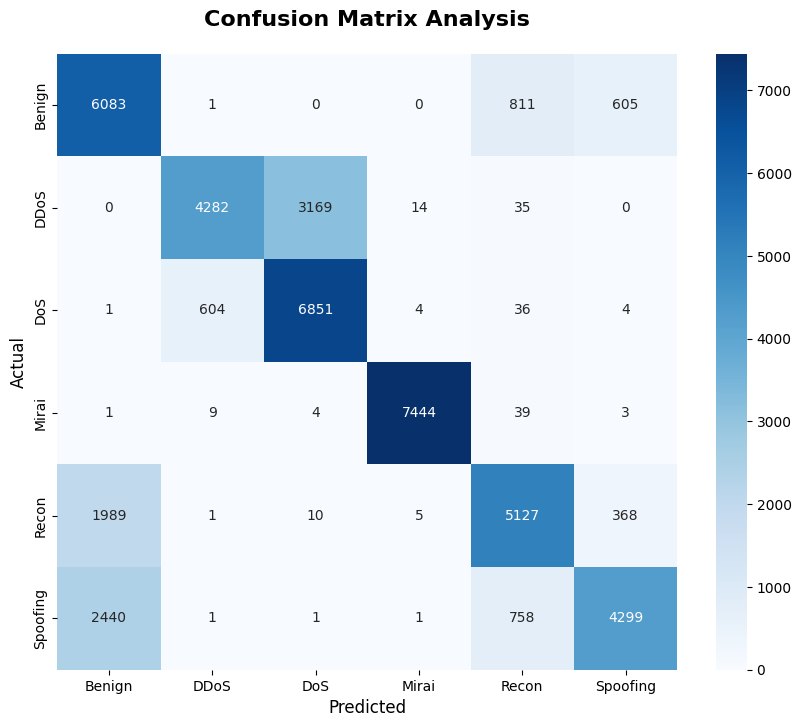

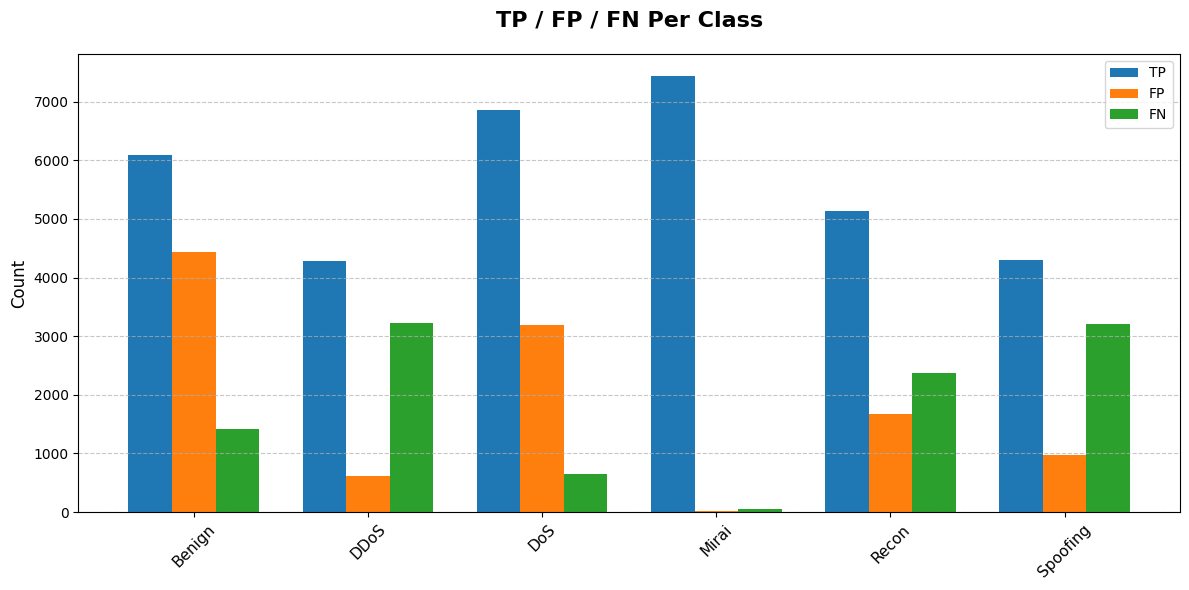

In [ ]:
import torch
import torch.nn as nn
from torch_geometric.nn import GATConv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

print("--- Initializing Standalone Analytics Engine ---")

# 1. Redefine the GAT Blueprint
class GAT(nn.Module):
    def __init__(self, hidden_channels, heads, in_dim, out_dim):
        super().__init__()
        torch.manual_seed(1234)
        self.conv1 = GATConv(in_dim, hidden_channels, heads)
        self.conv2 = GATConv(heads*hidden_channels, hidden_channels, heads)
        self.classifier = nn.Linear(heads*hidden_channels, out_dim)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index).relu()
        h = self.conv2(h, edge_index).relu()
        return self.classifier(h)

# 2. Load the Graph Data from Drive
print("Loading Graph Topology from Drive...")
graph_data = torch.load('/content/drive/MyDrive/GNN_IDS_Project/cic_iot_300k_graph.pt', weights_only=False)

# --- THE FIX: Re-apply the exact testing mask ---
print("Re-applying exact testing mask...")
indices = np.arange(graph_data.num_nodes)
labels = graph_data.y.numpy()

# Reproduce the exact 70/15/15 split using random_state=42
train_idx, temp_idx, _, temp_labels = train_test_split(
    indices, labels, test_size=0.3, stratify=labels, random_state=42
)
_, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=temp_labels, random_state=42
)

# Apply only the test mask for analytics
graph_data.test_mask = torch.zeros(graph_data.num_nodes, dtype=torch.bool)
graph_data.test_mask[test_idx] = True
# ------------------------------------------------

# 3. Initialize the Model Shell and Inject the Weights
print("Loading GAT Brains from Drive...")
in_dim = 46
hidden_dim = 20
out_dim = len(torch.unique(graph_data.y))
heads = 4

standalone_model = GAT(hidden_dim, heads, in_dim, out_dim)
# Make sure to set weights_only=True to comply with PyTorch 2.6 security
standalone_model.load_state_dict(torch.load('/content/drive/MyDrive/GNN_IDS_Project/GAT_300k_weights.pt', weights_only=True))
standalone_model.eval()

# 4. Extract Predictions
print("Calculating Predictions...")
with torch.no_grad():
    logits = standalone_model(graph_data.x, graph_data.edge_index)
    preds = torch.argmax(logits[graph_data.test_mask], dim=1).cpu().numpy()
    y_true = graph_data.y[graph_data.test_mask].cpu().numpy()

class_names = ['Benign', 'DDoS', 'DoS', 'Mirai', 'Recon', 'Spoofing']

# ==========================================
# OUTPUT 1: Detailed Classification Report
# ==========================================
print("\n--- Test Results ---")
print(classification_report(y_true, preds, target_names=class_names, digits=4))

# ==========================================
# OUTPUT 2: Confusion Matrix Heatmap
# ==========================================
cm = confusion_matrix(y_true, preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix Analysis', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

# ==========================================
# OUTPUT 3: TP, FP, FN Bar Chart
# ==========================================
FP = cm.sum(axis=0) - np.diag(cm)
FN = cm.sum(axis=1) - np.diag(cm)
TP = np.diag(cm)

x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width, TP, width, label='TP')
rects2 = ax.bar(x, FP, width, label='FP')
rects3 = ax.bar(x + width, FN, width, label='FN')

ax.set_ylabel('Count', fontsize=12)
ax.set_title('TP / FP / FN Per Class', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, fontsize=11)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

--- Initializing Comparative Benchmark Engine ---
Waking up all 4 AI brains...
Calculating mathematical metrics for all models. Please wait...

Table: Statistics on standard metrics (in percentage) of NN and GNN models
  Dataset  Model  Prec Recall F1-score   AUC  FPR
Dataset 1     NN 75.18  72.18    71.61 94.35 5.56
Dataset 1    GCN 74.72  72.97    72.54 95.18 5.41
Dataset 1 GCN-EW 70.17  69.86    69.75 93.22 6.03
Dataset 1    GAT 78.33  75.75    75.53 96.27 4.85



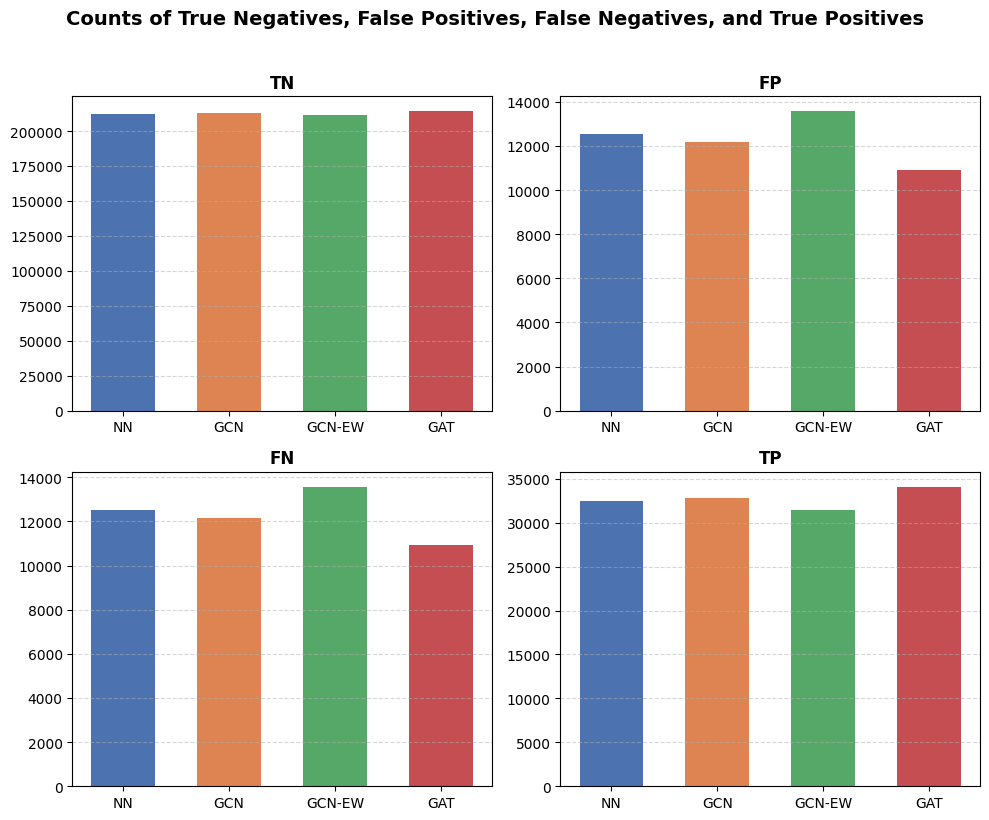

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split

print("--- Initializing Comparative Benchmark Engine ---")

# ==========================================
# 1. LOAD GRAPH & REBUILD MASKS
# ==========================================
graph_data = torch.load('/content/drive/MyDrive/GNN_IDS_Project/cic_iot_300k_graph.pt', weights_only=False)

indices = np.arange(graph_data.num_nodes)
labels = graph_data.y.numpy()

train_idx, temp_idx, _, temp_labels = train_test_split(indices, labels, test_size=0.3, stratify=labels, random_state=42)
_, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=temp_labels, random_state=42)

graph_data.test_mask = torch.zeros(graph_data.num_nodes, dtype=torch.bool)
graph_data.test_mask[test_idx] = True

# ==========================================
# 2. REDEFINE ALL FOUR BLUEPRINTS
# ==========================================
class NN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        torch.manual_seed(1234)
        self.lin1 = nn.Linear(in_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, hidden_dim)
        self.out_layer = nn.Linear(hidden_dim, out_dim)
    def forward(self, x, edge_index=None): # edge_index added to standardise the evaluation loop
        h = self.lin1(x).relu()
        h = self.lin2(h).relu()
        return self.out_layer(h)

class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        torch.manual_seed(1234)
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, out_dim)
    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index).relu()
        h = self.conv2(h, edge_index).relu()
        return self.classifier(h)

class GCN_EW(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, edge_index):
        super().__init__()
        torch.manual_seed(1234)
        self.edge_weight = torch.nn.Parameter(torch.zeros(edge_index.shape[1]))
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, out_dim)
    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index, torch.exp(self.edge_weight)).relu()
        h = self.conv2(h, edge_index, torch.exp(self.edge_weight)).relu()
        return self.classifier(h)

class GAT(nn.Module):
    def __init__(self, hidden_channels, heads, in_dim, out_dim):
        super().__init__()
        torch.manual_seed(1234)
        self.conv1 = GATConv(in_dim, hidden_channels, heads)
        self.conv2 = GATConv(heads*hidden_channels, hidden_channels, heads)
        self.classifier = nn.Linear(heads*hidden_channels, out_dim)
    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index).relu()
        h = self.conv2(h, edge_index).relu()
        return self.classifier(h)

# ==========================================
# 3. INITIALIZE MODELS & LOAD WEIGHTS
# ==========================================
in_dim = 46
hidden_dim = 20
out_dim = len(torch.unique(graph_data.y))
heads = 4
save_path = '/content/drive/MyDrive/GNN_IDS_Project/'

models = {
    "NN": NN(in_dim, hidden_dim, out_dim),
    "GCN": GCN(in_dim, hidden_dim, out_dim),
    "GCN-EW": GCN_EW(in_dim, hidden_dim, out_dim, graph_data.edge_index),
    "GAT": GAT(hidden_dim, heads, in_dim, out_dim)
}

# The exact filenames you saved earlier
weight_files = {
    "NN": "Baseline_NN_300k_weights.pt",
    "GCN": "GCN_300k_weights.pt",
    "GCN-EW": "GCN_EW_300k_weights.pt",
    "GAT": "GAT_300k_weights.pt"
}

print("Waking up all 4 AI brains...")
for name, model in models.items():
    model.load_state_dict(torch.load(save_path + weight_files[name], weights_only=True))
    model.eval()

# ==========================================
# 4. EVALUATION & METRICS EXTRACTION
# ==========================================
table_data = []
bar_data = {'TN': [], 'FP': [], 'FN': [], 'TP': []}
model_names = list(models.keys())

y_true = graph_data.y[graph_data.test_mask].numpy()

print("Calculating mathematical metrics for all models. Please wait...")
with torch.no_grad():
    for name, model in models.items():
        logits = model(graph_data.x, graph_data.edge_index)
        probs = F.softmax(logits[graph_data.test_mask], dim=1).numpy()
        preds = torch.argmax(logits[graph_data.test_mask], dim=1).numpy()

        # 1. Standard Metrics (Macro Averaged for Multi-class)
        prec = precision_score(y_true, preds, average='macro', zero_division=0) * 100
        rec = recall_score(y_true, preds, average='macro', zero_division=0) * 100
        f1 = f1_score(y_true, preds, average='macro', zero_division=0) * 100

        # AUC requires probabilities
        auc = roc_auc_score(y_true, probs, multi_class='ovr', average='macro') * 100

        # 2. Confusion Matrix Parsing for TN, FP, FN, TP
        cm = confusion_matrix(y_true, preds)

        FP = cm.sum(axis=0) - np.diag(cm)
        FN = cm.sum(axis=1) - np.diag(cm)
        TP = np.diag(cm)
        TN = cm.sum() - (FP + FN + TP)

        # False Positive Rate = FP / (FP + TN)
        fpr_array = FP / (FP + TN)
        fpr = np.mean(fpr_array) * 100 # Average FPR across all 6 classes

        # Store for Table
        table_data.append(["Dataset 1", name, f"{prec:.2f}", f"{rec:.2f}", f"{f1:.2f}", f"{auc:.2f}", f"{fpr:.2f}"])

        # Store Sums for Bar Charts
        bar_data['TN'].append(TN.sum())
        bar_data['FP'].append(FP.sum())
        bar_data['FN'].append(FN.sum())
        bar_data['TP'].append(TP.sum())

# ==========================================
# OUTPUT 1: The Formatted Table
# ==========================================
print("\n" + "="*80)
print("Table: Statistics on standard metrics (in percentage) of NN and GNN models")
print("="*80)
df = pd.DataFrame(table_data, columns=["Dataset", "Model", "Prec", "Recall", "F1-score", "AUC", "FPR"])
print(df.to_string(index=False))
print("="*80 + "\n")

# ==========================================
# OUTPUT 2: The 2x2 Benchmark Plot
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52'] # Matching research paper colors
x_pos = np.arange(len(model_names))

# Helper function to format subplots
def setup_ax(ax, title, data):
    ax.bar(x_pos, data, color=colors, width=0.6)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_names)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

setup_ax(axs[0, 0], 'TN', bar_data['TN'])
setup_ax(axs[0, 1], 'FP', bar_data['FP'])
setup_ax(axs[1, 0], 'FN', bar_data['FN'])
setup_ax(axs[1, 1], 'TP', bar_data['TP'])

plt.suptitle('Counts of True Negatives, False Positives, False Negatives, and True Positives', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()